In [1]:
pip install requests beautifulsoup4 pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Web Scraping Project - Job Listings Data

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

#url
url="https://realpython.github.io/fake-jobs/"

#Send request
response=requests.get(url)

#Parse HTMl
soup=BeautifulSoup(response.text,"html.parser")

#Find all job cards
jobs=soup.find_all("div",class_="card-content")

#Empty list to store data
data=[]

#Loop through each job
for job in jobs:
    title=job.find("h2",class_="title").text.strip()
    company=job.find("h3",class_="company").text.strip()
    location=job.find("p",class_="location").text.strip()

    data.append({
        "Job Title":title,
        "Company":company,
        "Location":location
    })

#Convert to DataFrame
df=pd.DataFrame(data)

#Save to CSV
df.to_csv("jobs_data.csv",index=False)

print("Data scraped successfully!")
print(df.head())

Data scraped successfully!
                 Job Title                     Company              Location
0  Senior Python Developer    Payne, Roberts and Davis       Stewartbury, AA
1          Energy engineer            Vasquez-Davidson  Christopherville, AA
2          Legal executive  Jackson, Chambers and Levy   Port Ericaburgh, AA
3   Fitness centre manager              Savage-Bradley     East Seanview, AP
4          Product manager                 Ramirez Inc   North Jamieview, AP


In [9]:
import os
print(os.getcwd())

C:\Users\Puja Tudu


In [13]:
#Remove Extra space
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Job Title  100 non-null    object
 1   Company    100 non-null    object
 2   Location   100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


Job Title    0
Company      0
Location     0
dtype: int64

In [15]:
df["Job Title"]=df["Job Title"].str.strip()
df["Company"]=df["Company"].str.strip()
df["Location"]=df["Location"].str.strip()
print(df.head())

                 Job Title                     Company              Location
0  Senior Python Developer    Payne, Roberts and Davis       Stewartbury, AA
1          Energy engineer            Vasquez-Davidson  Christopherville, AA
2          Legal executive  Jackson, Chambers and Levy   Port Ericaburgh, AA
3   Fitness centre manager              Savage-Bradley     East Seanview, AP
4          Product manager                 Ramirez Inc   North Jamieview, AP


In [16]:
#Remove Duplicates
df=df.drop_duplicates(subset=["Job Title","Company","Location"])

In [17]:
#Handle missing values
df=df.dropna()

In [19]:
df["Loaction"]=df["Location"].str.title()
df["Company"]=df["Company"].str.title()
print(df.head())

                 Job Title                     Company              Location  \
0  Senior Python Developer    Payne, Roberts And Davis       Stewartbury, AA   
1          Energy engineer            Vasquez-Davidson  Christopherville, AA   
2          Legal executive  Jackson, Chambers And Levy   Port Ericaburgh, AA   
3   Fitness centre manager              Savage-Bradley     East Seanview, AP   
4          Product manager                 Ramirez Inc   North Jamieview, AP   

               Loaction  
0       Stewartbury, Aa  
1  Christopherville, Aa  
2   Port Ericaburgh, Aa  
3     East Seanview, Ap  
4   North Jamieview, Ap  


In [20]:
#Save Cleaned dataset
df.to_csv("jobs_data_cleaned.csv",index=False)

In [21]:
df.head()
df.shape

(100, 4)

In [22]:
df.columns

Index(['Job Title', 'Company', 'Location', 'Loaction'], dtype='object')

In [25]:
df=df.drop(columns=["Location"])

In [26]:
df.head()
df.shape

(100, 3)

In [2]:
import pandas as pd

df = pd.read_csv("jobs_data.csv")

### Top 10 Job Title

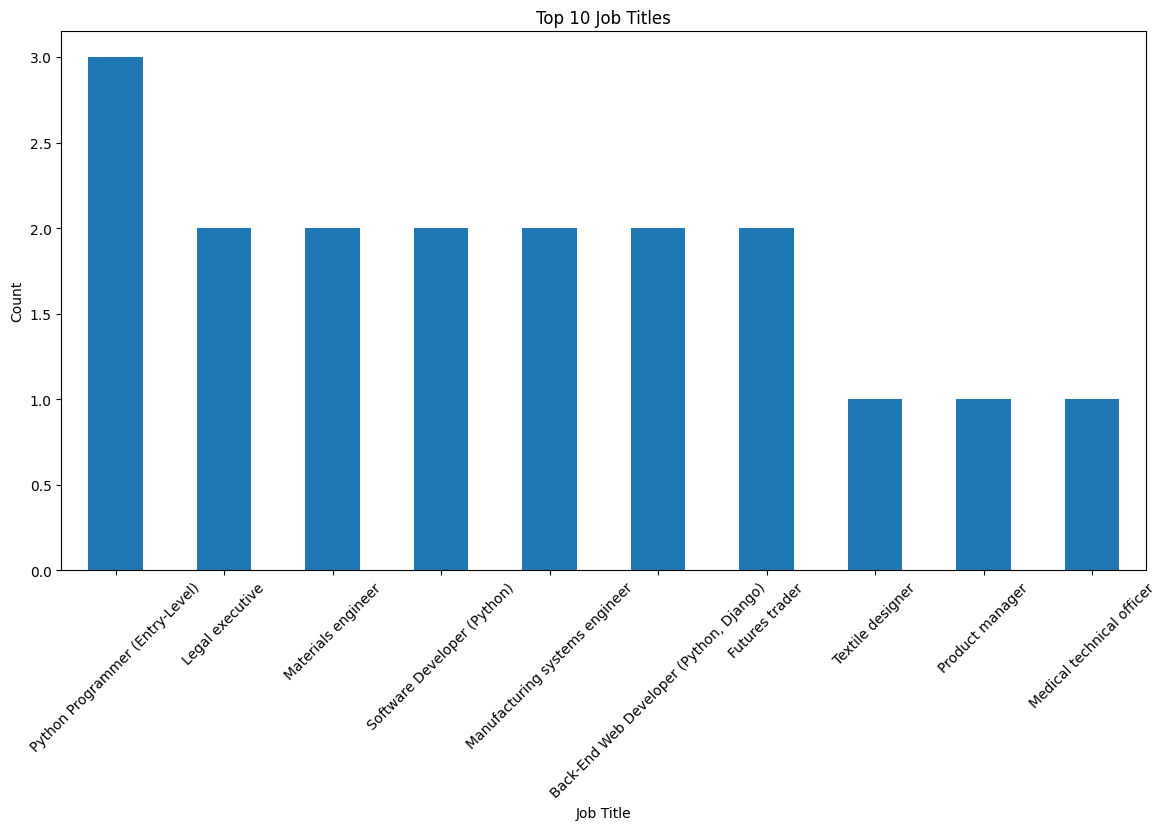

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

df["Job Title"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Top 5 Job Location

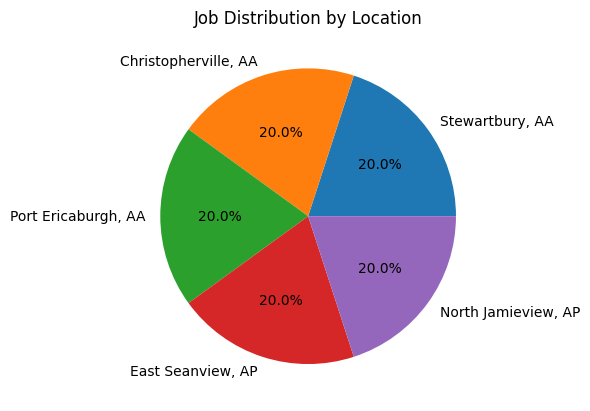

In [9]:
df["Location"].value_counts().head(5).plot(kind="pie", autopct="%1.1f%%")

plt.title("Job Distribution by Location")
plt.ylabel("")
plt.show()